# Multi-Seed Summary — Mean ± Std Across 3 Independent Runs

Aggregates results from all three training seeds and computes mean ± std for
every KPI and reward metric.  This is the report-ready statistical summary.

| Run | Seed | Results folder |
|-----|------|---------------|
| Seed 1 | 42 | `results_250k/` |
| Seed 2 | 2  | `results_250k_seed2/` |
| Seed 3 | 7  | `results_250k_seed3/` |

All conditions evaluated on the US training climate using `local_individual`
reward mode so reward magnitudes are comparable across algorithms.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display, Image

Path("results_multiseed").mkdir(exist_ok=True)

SEEDS = [
    {"label": "seed1", "seed": 42, "folder": "results_250k 6a seed1"},
    {"label": "seed2", "seed": 2,  "folder": "results_250k_seed2 6b"},
    {"label": "seed3", "seed": 7,  "folder": "results_250k_seed3 6c"},
]

CONDITIONS = [
    ("ippo",    "flat_shared"),
    ("ippo",    "local_individual"),
    ("ippo",    "uae_weighted"),
    ("mappo",   "flat_shared"),
    ("mappo",   "local_individual"),
    ("mappo",   "uae_weighted"),
    ("neutral", "neutral"),
]

KPI_NAMES = [
    "cost_total",
    "carbon_emissions_total",
    "discomfort_proportion",
    "ramping_average",
    "daily_one_minus_load_factor_average",
]

COND_LABELS = [f"{a}|{r}" for a, r in CONDITIONS]
COLORS = {"flat_shared": "#4C78A8", "local_individual": "#F58518",
          "uae_weighted": "#E45756", "neutral": "#aaaaaa"}
MARKERS = {"ippo": "o", "mappo": "s", "neutral": "D"}

print("Seed folders:")
for s in SEEDS:
    p = Path(s["folder"]) / "summary"
    exists = p.exists()
    print(f"  {s['label']} (seed={s['seed']}) -> {p}  {'OK' if exists else 'MISSING'}")


Seed folders:
  seed1 (seed=42) -> results_250k 6a seed1/summary  OK
  seed2 (seed=2) -> results_250k_seed2 6b/summary  OK
  seed3 (seed=7) -> results_250k_seed3 6c/summary  OK


## 1 · Load Results from All Seeds

In [2]:
reward_frames, kpi_frames, pct_frames = [], [], []

for s in SEEDS:
    folder = Path(s["folder"]) / "summary"
    rdf = pd.read_csv(folder / "all_rewards.csv")
    kdf = pd.read_csv(folder / "all_kpis.csv")
    rdf["seed_label"] = s["label"]
    kdf["seed_label"] = s["label"]
    reward_frames.append(rdf)
    kpi_frames.append(kdf)
    pct_f = folder / "pct_change_vs_neutral.csv"
    if pct_f.exists():
        pdf = pd.read_csv(pct_f)
        pdf["seed_label"] = s["label"]
        pct_frames.append(pdf)

all_rewards = pd.concat(reward_frames, ignore_index=True)
all_kpis    = pd.concat(kpi_frames,    ignore_index=True)
all_pct     = pd.concat(pct_frames,    ignore_index=True) if pct_frames else pd.DataFrame()

print(f"Loaded {len(SEEDS)} seeds  x  {all_rewards['algorithm'].nunique()} algorithms")
print(f"Total reward rows: {len(all_rewards)}")
print(f"Total KPI rows:    {len(all_kpis)}")


Loaded 3 seeds  x  3 algorithms
Total reward rows: 21
Total KPI rows:    105


## 2 · Mean ± Std Reward Table

Primary comparison metric. Higher reward = better (all rewards are negative costs).


In [3]:
reward_stats = (
    all_rewards
    .groupby(["algorithm", "reward_mode"])["mean_agent_reward"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
    .rename(columns={"mean": "reward_mean", "std": "reward_std",
                      "min": "reward_min",  "max": "reward_max"})
    .sort_values("reward_mean", ascending=False)
)
reward_stats["mean_pm_std"] = (
    reward_stats["reward_mean"].round(2).astype(str) + " ± " +
    reward_stats["reward_std"].round(2).astype(str)
)
reward_stats.to_csv("results_multiseed/reward_mean_std.csv", index=False)

print("=== Reward: Mean ± Std across 3 seeds (higher = better) ===")
display(reward_stats[["algorithm", "reward_mode", "mean_pm_std",
                       "reward_min", "reward_max"]].round(2))


=== Reward: Mean ± Std across 3 seeds (higher = better) ===


,algorithm,reward_mode,mean_pm_std,reward_min,reward_max
6,neutral,neutral,-266.34 ± 0.0,-266.34,-266.34
1,ippo,local_individual,-267.79 ± 2.33,-270.02,-265.37
4,mappo,local_individual,-279.57 ± 2.05,-281.02,-277.23
5,mappo,uae_weighted,-285.3 ± 4.04,-288.83,-280.90
3,mappo,flat_shared,-293.78 ± 1.06,-294.57,-292.57
2,ippo,uae_weighted,-296.62 ± 4.2,-300.64,-292.26
0,ippo,flat_shared,-297.36 ± 8.7,-306.51,-289.20


## 3 · Mean ± Std per KPI

In [4]:
kpi_stats = (
    all_kpis[all_kpis["cost_function"].isin(KPI_NAMES)]
    .groupby(["algorithm", "reward_mode", "cost_function"])["value"]
    .agg(["mean", "std"])
    .reset_index()
)
kpi_stats["mean_pm_std"] = (
    kpi_stats["mean"].round(4).astype(str) + " ± " +
    kpi_stats["std"].round(4).astype(str)
)

# Pivot for easy reading
kpi_pivot = kpi_stats.pivot_table(
    index=["algorithm", "reward_mode"],
    columns="cost_function",
    values=["mean", "std"],
)
kpi_pivot.to_csv("results_multiseed/kpi_mean_std_pivot.csv")

# Clean display table
display_rows = []
for (algo, rm), grp in kpi_stats.groupby(["algorithm", "reward_mode"]):
    row = {"algorithm": algo, "reward_mode": rm}
    for _, kr in grp.iterrows():
        row[kr["cost_function"]] = f"{kr['mean']:.4f} ± {kr['std']:.4f}"
    display_rows.append(row)
display_df = pd.DataFrame(display_rows)
display_df.to_csv("results_multiseed/kpi_summary_table.csv", index=False)

print("=== KPI Mean ± Std across 3 seeds (lower = better for all KPIs) ===")
display(display_df)


=== KPI Mean ± Std across 3 seeds (lower = better for all KPIs) ===


,algorithm,reward_mode,carbon_emissions_total,cost_total,daily_one_minus_load_factor_average,discomfort_proportion,ramping_average
0,ippo,flat_shared,0.4890 ± 0.0165,0.4609 ± 0.0225,1.3412 ± 0.0025,0.9581 ± 0.0133,0.9631 ± 0.0276
1,ippo,local_individual,0.4553 ± 0.0073,0.4218 ± 0.0080,1.3308 ± 0.0091,0.9713 ± 0.0002,0.8714 ± 0.0177
2,ippo,uae_weighted,0.4800 ± 0.0149,0.4530 ± 0.0221,1.3360 ± 0.0036,0.9651 ± 0.0071,0.9659 ± 0.0300
3,mappo,flat_shared,0.4837 ± 0.0050,0.4540 ± 0.0033,1.3185 ± 0.0080,0.9628 ± 0.0007,0.9618 ± 0.0080
4,mappo,local_individual,0.4638 ± 0.0043,0.4336 ± 0.0036,1.3190 ± 0.0165,0.9707 ± 0.0013,0.8936 ± 0.0165
5,mappo,uae_weighted,0.4654 ± 0.0078,0.4362 ± 0.0050,1.3185 ± 0.0145,0.9687 ± 0.0013,0.9336 ± 0.0094
6,neutral,neutral,0.4300 ± 0.0000,0.4024 ± 0.0000,1.3722 ± 0.0000,0.9727 ± 0.0000,0.8734 ± 0.0000


## 4 · % Change vs Neutral Baseline (Mean ± Std)

How much each condition improves or worsens relative to the neutral (no-action)
baseline, averaged across seeds.  Negative = improvement.


In [5]:
pct_kpi_cols = [c for c in all_pct.columns if c.endswith("_pct_vs_neutral")]

pct_stats = (
    all_pct
    .groupby(["algorithm", "reward_mode"])[pct_kpi_cols]
    .agg(["mean", "std"])
    .reset_index()
)
# Flatten multi-level columns
pct_stats.columns = [
    "_".join(c).strip("_") if c[1] else c[0]
    for c in pct_stats.columns.values
]
pct_stats.to_csv("results_multiseed/pct_change_vs_neutral_mean_std.csv", index=False)

# Compact display: mean only with std in brackets
compact_rows = []
for (algo, rm), grp in all_pct.groupby(["algorithm", "reward_mode"]):
    row = {"algorithm": algo, "reward_mode": rm}
    for col in pct_kpi_cols:
        m = grp[col].mean(); s = grp[col].std()
        short = col.replace("_pct_vs_neutral", "").replace("_total","").replace("daily_","")
        row[short] = f"{m:+.1f} ± {s:.1f}%"
    compact_rows.append(row)
compact_df = pd.DataFrame(compact_rows)
compact_df.to_csv("results_multiseed/pct_change_compact.csv", index=False)

print("=== % Change vs Neutral — Mean ± Std (negative = better) ===")
display(compact_df)


=== % Change vs Neutral — Mean ± Std (negative = better) ===


,algorithm,reward_mode,cost,carbon_emissions,discomfort_proportion,ramping_average,one_minus_load_factor_average
0,ippo,flat_shared,+14.5 ± 5.6%,+13.7 ± 3.8%,-1.5 ± 1.4%,+10.3 ± 3.2%,-2.3 ± 0.2%
1,ippo,local_individual,+4.8 ± 2.0%,+5.9 ± 1.7%,-0.1 ± 0.0%,-0.2 ± 2.0%,-3.0 ± 0.7%
2,ippo,uae_weighted,+12.6 ± 5.5%,+11.6 ± 3.5%,-0.8 ± 0.7%,+10.6 ± 3.4%,-2.6 ± 0.3%
3,mappo,flat_shared,+12.8 ± 0.8%,+12.5 ± 1.2%,-1.0 ± 0.1%,+10.1 ± 0.9%,-3.9 ± 0.6%
4,mappo,local_individual,+7.8 ± 0.9%,+7.9 ± 1.0%,-0.2 ± 0.1%,+2.3 ± 1.9%,-3.9 ± 1.2%
5,mappo,uae_weighted,+8.4 ± 1.3%,+8.2 ± 1.8%,-0.4 ± 0.1%,+6.9 ± 1.1%,-3.9 ± 1.1%


## 5 · Per-Seed Comparison (for reproducibility section)

In [6]:
per_seed = all_rewards.pivot_table(
    index=["algorithm", "reward_mode"],
    columns="seed_label",
    values="mean_agent_reward",
).round(2)
per_seed["mean"]  = per_seed.mean(axis=1).round(2)
per_seed["std"]   = per_seed.std(axis=1).round(2)
per_seed["range"] = (per_seed[["seed1","seed2","seed3"]].max(axis=1)
                    - per_seed[["seed1","seed2","seed3"]].min(axis=1)).round(2)
per_seed = per_seed.sort_values("mean", ascending=False)
per_seed.to_csv("results_multiseed/per_seed_reward_comparison.csv")

print("=== Per-seed reward — ranking consistent across seeds means results are stable ===")
display(per_seed)


=== Per-seed reward — ranking consistent across seeds means results are stable ===


seed_label                   seed1   seed2   seed3    mean   std  range
algorithm reward_mode                                                  
neutral   neutral          -266.34 -266.34 -266.34 -266.34  0.00   0.00
ippo      local_individual -265.37 -270.02 -267.97 -267.79  1.90   4.65
mappo     local_individual -277.23 -281.02 -280.47 -279.57  1.67   3.79
          uae_weighted     -280.90 -288.83 -286.18 -285.30  3.30   7.93
          flat_shared      -292.57 -294.57 -294.19 -293.78  0.87   2.00
ippo      uae_weighted     -300.64 -292.26 -296.97 -296.62  3.43   8.38
          flat_shared      -306.51 -289.20 -296.38 -297.36  7.10  17.31

## 6 · Plots

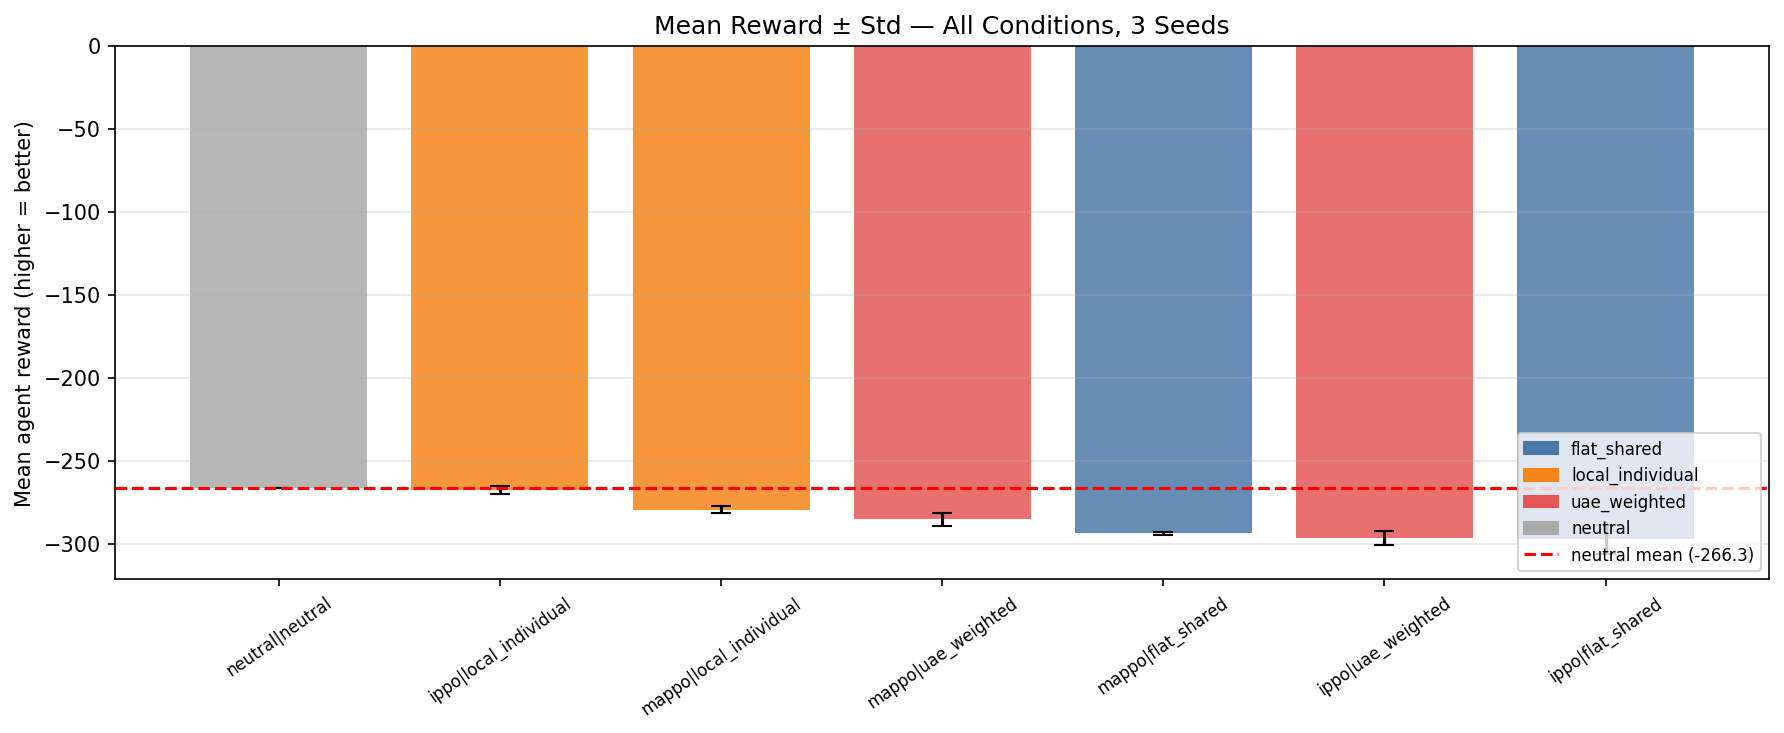

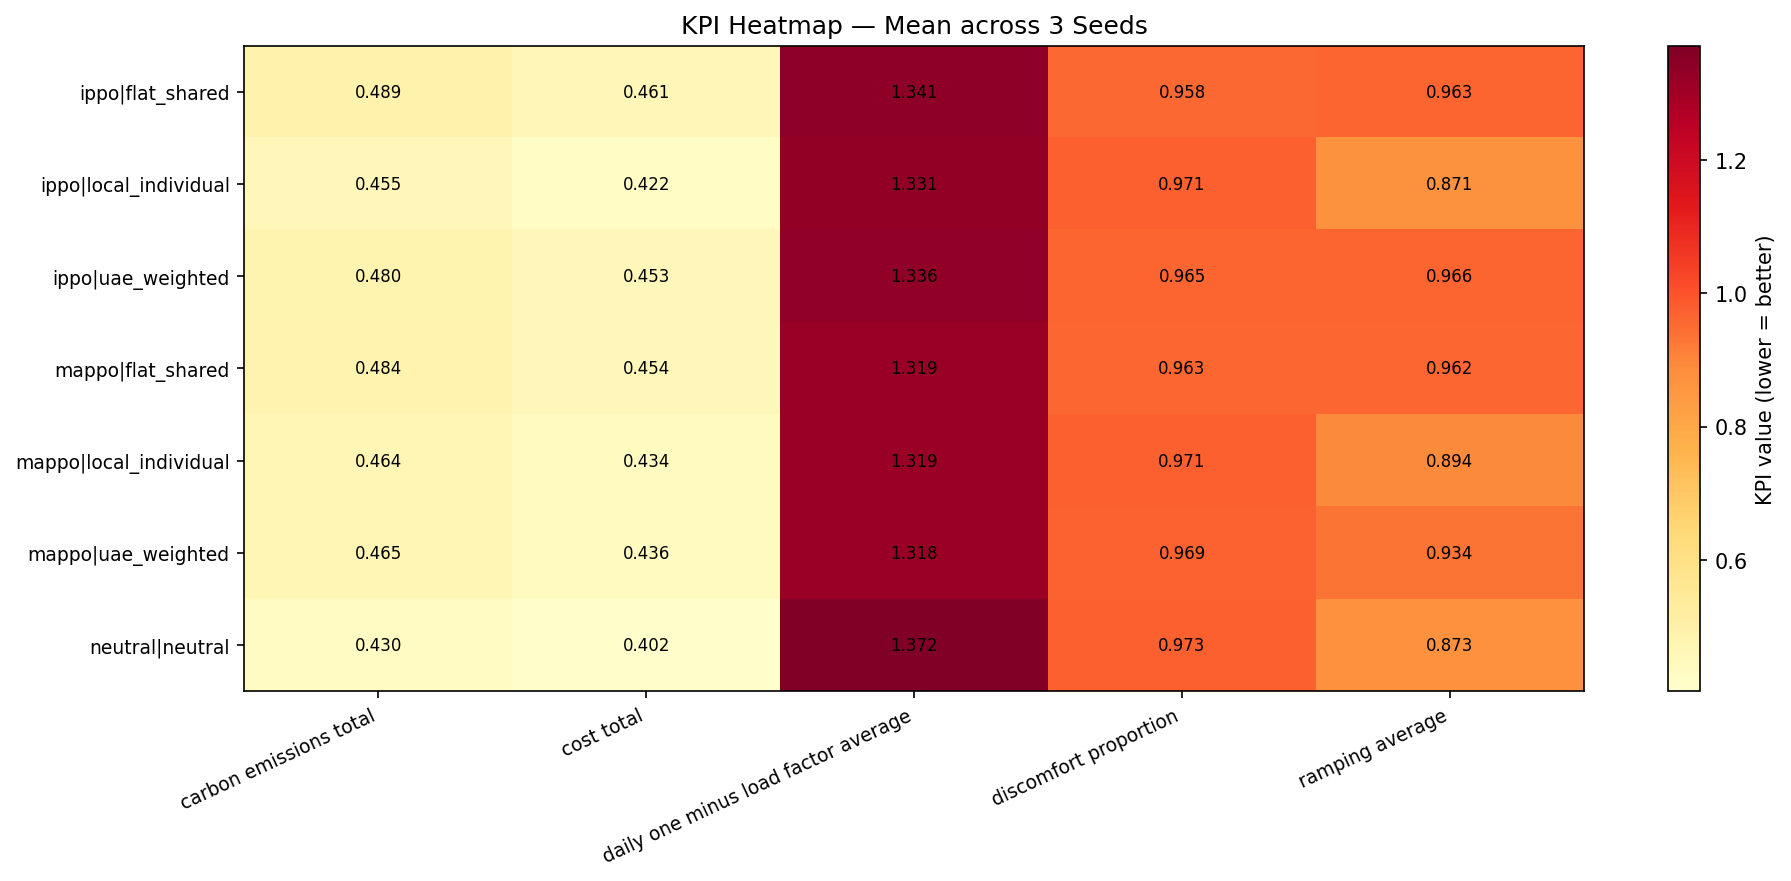

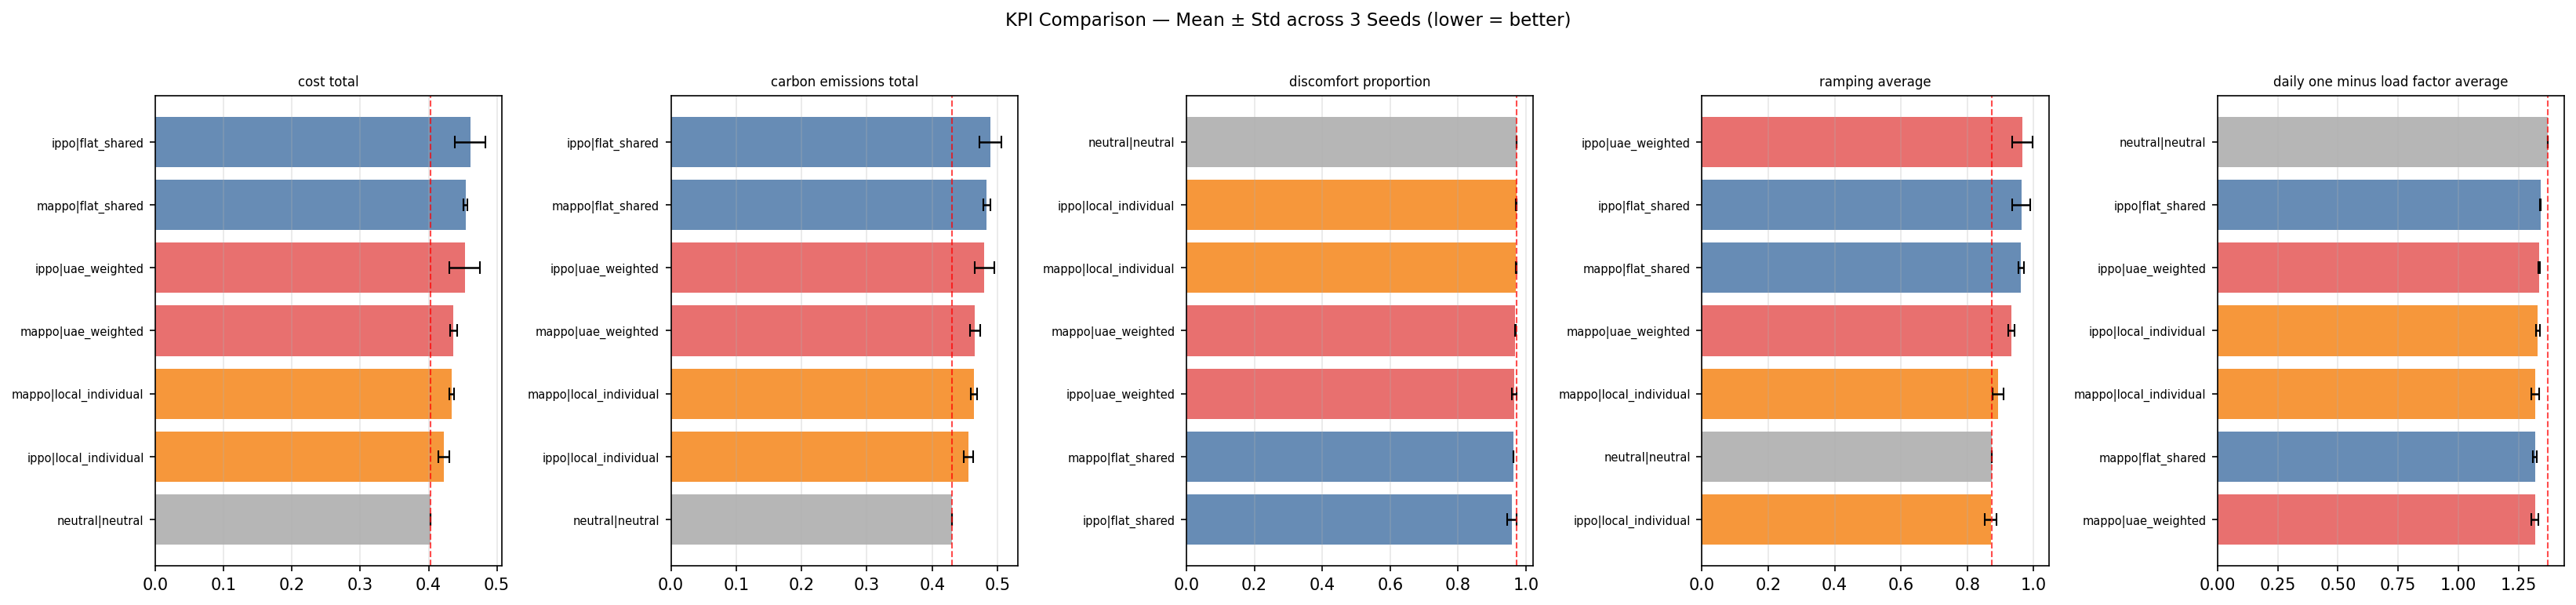

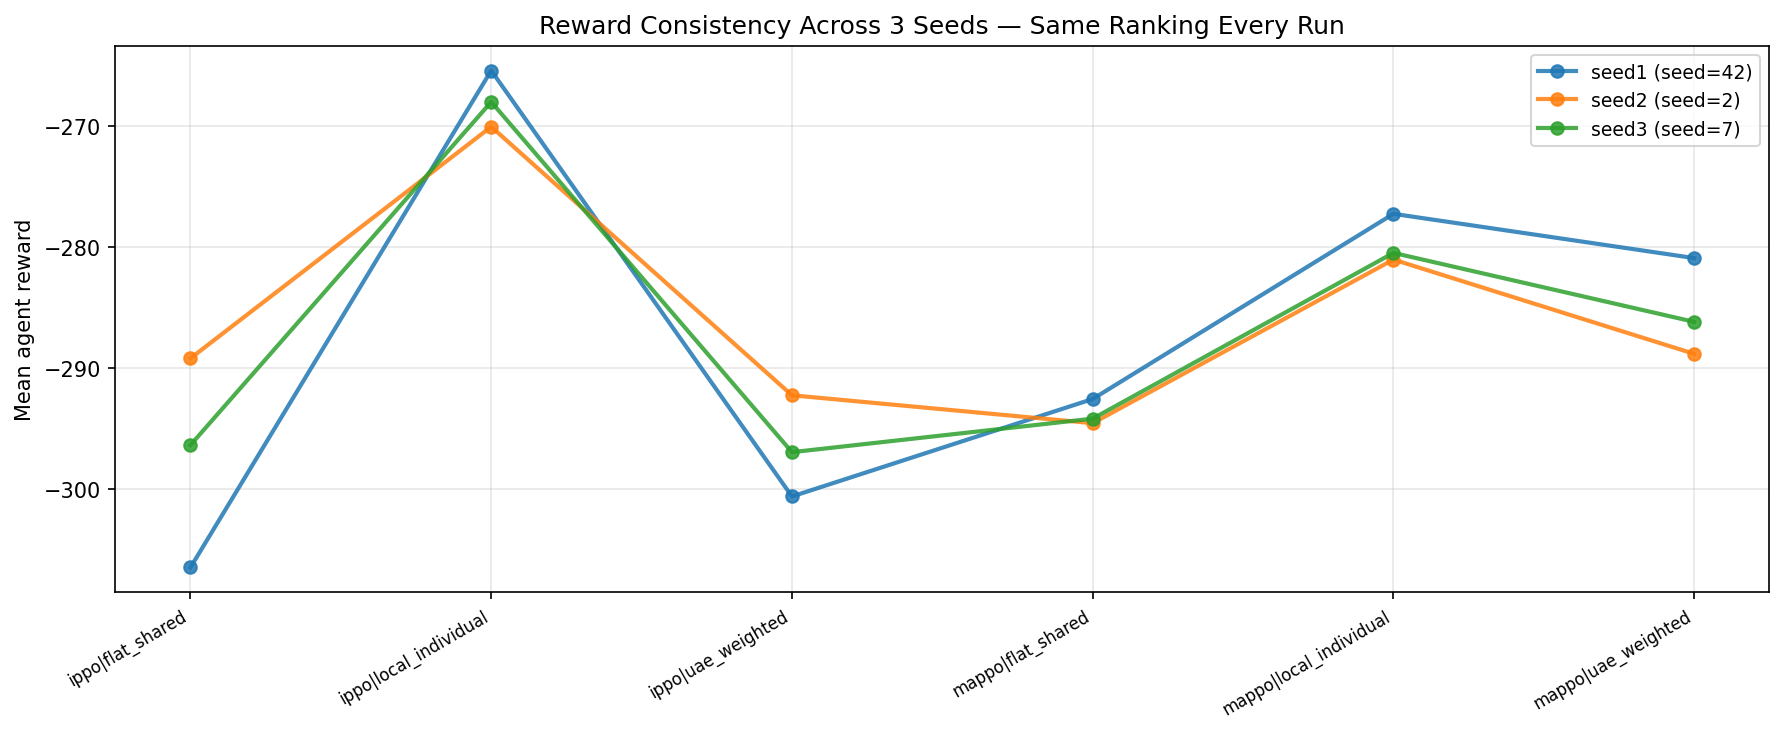

In [7]:
# ── Reward bar chart with std error bars ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
rs = reward_stats.copy()
rs["label"] = rs["algorithm"] + "|" + rs["reward_mode"]
rs = rs.sort_values("reward_mean", ascending=False)
bar_colors = [COLORS.get(r, "#888888") for r in rs["reward_mode"]]
bars = ax.bar(rs["label"], rs["reward_mean"], color=bar_colors, alpha=0.85,
              yerr=rs["reward_std"], capsize=5, error_kw={"lw": 1.5})

neutral_mean = float(rs[rs["algorithm"] == "neutral"]["reward_mean"].iloc[0])
ax.axhline(neutral_mean, color="red", lw=1.5, ls="--", label=f"neutral mean ({neutral_mean:.1f})")
ax.set_title("Mean Reward ± Std — All Conditions, 3 Seeds", fontsize=12)
ax.set_ylabel("Mean agent reward (higher = better)")
ax.tick_params(axis="x", rotation=35, labelsize=8)
ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=9)

from matplotlib.patches import Patch
legend_patches = [Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0][-1:],
          fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig("results_multiseed/reward_mean_std_bar.png", dpi=150, bbox_inches="tight")
plt.close(fig)
display(Image("results_multiseed/reward_mean_std_bar.png"))

# ── KPI heatmap — mean values ─────────────────────────────────────────────────
kpi_mean_only = (
    all_kpis[all_kpis["cost_function"].isin(KPI_NAMES)]
    .groupby(["algorithm", "reward_mode", "cost_function"])["value"]
    .mean()
    .reset_index()
)
heat_pivot = kpi_mean_only.pivot_table(
    index=["algorithm", "reward_mode"],
    columns="cost_function",
    values="value",
)
fig2, ax2 = plt.subplots(figsize=(13, 6))
im = ax2.imshow(heat_pivot.values.astype(float), cmap="YlOrRd", aspect="auto")
ax2.set_xticks(range(len(heat_pivot.columns)))
ax2.set_xticklabels([c.replace("_"," ") for c in heat_pivot.columns],
                    rotation=25, ha="right", fontsize=9)
ax2.set_yticks(range(len(heat_pivot.index)))
ax2.set_yticklabels([f"{a}|{r}" for a, r in heat_pivot.index], fontsize=9)
for i in range(len(heat_pivot.index)):
    for j in range(len(heat_pivot.columns)):
        v = heat_pivot.values[i, j]
        if not np.isnan(v):
            ax2.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax2, label="KPI value (lower = better)")
ax2.set_title("KPI Heatmap — Mean across 3 Seeds", fontsize=12)
plt.tight_layout()
plt.savefig("results_multiseed/kpi_heatmap_multiseed.png", dpi=150, bbox_inches="tight")
plt.close(fig2)
display(Image("results_multiseed/kpi_heatmap_multiseed.png"))

# ── Per-KPI bar charts with error bars ────────────────────────────────────────
fig3, axes3 = plt.subplots(1, len(KPI_NAMES), figsize=(22, 5))
for ax, kpi in zip(axes3, KPI_NAMES):
    sub = kpi_stats[kpi_stats["cost_function"] == kpi].copy()
    sub["label"] = sub["algorithm"] + "|" + sub["reward_mode"]
    sub = sub.sort_values("mean")
    colors = [COLORS.get(r, "#888") for r in sub["reward_mode"]]
    ax.barh(sub["label"], sub["mean"], xerr=sub["std"],
            color=colors, alpha=0.85, capsize=4, error_kw={"lw": 1.2})
    neutral_val = float(sub[sub["algorithm"] == "neutral"]["mean"].iloc[0]) if "neutral" in sub["algorithm"].values else np.nan
    if not np.isnan(neutral_val):
        ax.axvline(neutral_val, color="red", lw=1, ls="--", alpha=0.7)
    ax.set_title(kpi.replace("_", " "), fontsize=8)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(axis="y", labelsize=7)
plt.suptitle("KPI Comparison — Mean ± Std across 3 Seeds (lower = better)",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("results_multiseed/kpi_all_mean_std.png", dpi=150, bbox_inches="tight")
plt.close(fig3)
display(Image("results_multiseed/kpi_all_mean_std.png"))

# ── Seed consistency plot ─────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(12, 5))
x = np.arange(len(CONDITIONS) - 1)  # exclude neutral
non_neutral = [(a, r) for a, r in CONDITIONS if a != "neutral"]
for i, s in enumerate(SEEDS):
    rdf = reward_frames[i]
    vals = []
    for algo, rm in non_neutral:
        v = rdf[(rdf["algorithm"] == algo) & (rdf["reward_mode"] == rm)]["mean_agent_reward"]
        vals.append(float(v.iloc[0]) if len(v) else np.nan)
    ax4.plot(x, vals, marker="o", lw=2, label=f"{s['label']} (seed={s['seed']})", alpha=0.85)
ax4.set_xticks(x)
ax4.set_xticklabels([f"{a}|{r}" for a, r in non_neutral], rotation=30, ha="right", fontsize=8)
ax4.set_ylabel("Mean agent reward")
ax4.set_title("Reward Consistency Across 3 Seeds — Same Ranking Every Run")
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results_multiseed/seed_consistency.png", dpi=150, bbox_inches="tight")
plt.close(fig4)
display(Image("results_multiseed/seed_consistency.png"))


## 7 · Report-Ready Summary

In [8]:
# Best conditions per KPI (mean across seeds)
print("=== Best condition per KPI (lowest mean value) ===")
for kpi in KPI_NAMES:
    sub = kpi_stats[(kpi_stats["cost_function"] == kpi) &
                    (kpi_stats["algorithm"] != "neutral")]
    best = sub.loc[sub["mean"].idxmin()]
    print(f"  {kpi:<45} -> {best['algorithm']} | {best['reward_mode']}"
          f"   mean={best['mean']:.4f} ± {best['std']:.4f}")

print()
print("=== Conditions that beat neutral baseline (mean reward > neutral mean) ===")
neutral_reward = float(reward_stats[reward_stats["algorithm"] == "neutral"]["reward_mean"].iloc[0])
beats = reward_stats[
    (reward_stats["algorithm"] != "neutral") &
    (reward_stats["reward_mean"] > neutral_reward)
]
if len(beats):
    for _, row in beats.iterrows():
        margin = row["reward_mean"] - neutral_reward
        print(f"  {row['algorithm']} | {row['reward_mode']:<20} "
              f"mean={row['reward_mean']:.2f} ± {row['reward_std']:.2f}  "
              f"(+{margin:.2f} above neutral)")
else:
    print("  None beat neutral on mean reward.")

print()
print("=== Ranking stability — same top-2 in all 3 seeds? ===")
for s in SEEDS:
    rdf = reward_frames[[i for i,x in enumerate(SEEDS) if x["label"]==s["label"]][0]]
    top2 = rdf[rdf["algorithm"]!="neutral"].nlargest(2,"mean_agent_reward")[["algorithm","reward_mode","mean_agent_reward"]]
    print(f"  {s['label']}: " + "  |  ".join(f"{r['algorithm']}|{r['reward_mode']} ({r['mean_agent_reward']:.1f})" for _,r in top2.iterrows()))


=== Best condition per KPI (lowest mean value) ===
  cost_total                                    -> ippo | local_individual   mean=0.4218 ± 0.0080
  carbon_emissions_total                        -> ippo | local_individual   mean=0.4553 ± 0.0073
  discomfort_proportion                         -> ippo | flat_shared   mean=0.9581 ± 0.0133
  ramping_average                               -> ippo | local_individual   mean=0.8714 ± 0.0177
  daily_one_minus_load_factor_average           -> mappo | uae_weighted   mean=1.3185 ± 0.0145

=== Conditions that beat neutral baseline (mean reward > neutral mean) ===
  None beat neutral on mean reward.

=== Ranking stability — same top-2 in all 3 seeds? ===
  seed1: ippo|local_individual (-265.4)  |  mappo|local_individual (-277.2)
  seed2: ippo|local_individual (-270.0)  |  mappo|local_individual (-281.0)
  seed3: ippo|local_individual (-268.0)  |  mappo|local_individual (-280.5)


## Output Files

```
results_multiseed/
  reward_mean_std.csv               ← mean ± std reward for all conditions
  kpi_mean_std_pivot.csv            ← full KPI pivot table
  kpi_summary_table.csv             ← clean KPI table for report
  pct_change_vs_neutral_mean_std.csv← % change vs neutral with error bars
  pct_change_compact.csv            ← compact version for report tables
  per_seed_reward_comparison.csv    ← per-seed values + mean + std + range
  reward_mean_std_bar.png           ← bar chart with error bars
  kpi_heatmap_multiseed.png         ← KPI heatmap (mean across seeds)
  kpi_all_mean_std.png              ← per-KPI bar charts with error bars
  seed_consistency.png              ← line chart showing same ranking every seed
```
